# Part 6: Training — From Scratch to Flax

**Goal**: Build a complete neural network training pipeline three ways, each a natural evolution of the last. By the end you'll be able to train a model from scratch, with Flax, and with Optax — and understand exactly what each layer adds.

---

## Table of Contents

1. **Training from Scratch** — pytrees + vmap + jit (the full picture)
2. **The Boilerplate Problem** — what gets tedious at scale
3. **Training with Flax** — `nn.Module`, `init`, `apply`
4. **Training with Optax** — Adam and the optimizer protocol
5. **For Inference Engineers** — what you actually need
6. **Summary — What To Do Next**

---

> **Prerequisites**: This notebook builds on **Notebooks 01–05**. You need to be comfortable with pytrees, vmap, and jit before starting here.

> **Note on focus**: This tutorial series is primarily about understanding JAX itself. Training pipelines use JAX, but the specifics of Flax and Optax are deep topics. We cover enough here to get you running — see the links in the Summary for deeper dives.

In [1]:
# @title Setup { display-mode: "form" }

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
# Optional: install flax and optax if not present
# !pip install flax optax -q

import flax.linen as nn
import optax

print(f"JAX version:   {jax.__version__}")
print(f"Backend:       {jax.default_backend()}")

JAX version:   0.9.2
Backend:       cpu


In [2]:
# @title Shared Data and From-Scratch Utilities { display-mode: "form" }

# Dataset — two interleaved half-moons (pure numpy, no sklearn needed)
key = jax.random.PRNGKey(42)

def make_moons(n_samples=1000, noise=0.15, seed=0):
    rng = np.random.RandomState(seed)
    n = n_samples // 2
    t = np.linspace(0, np.pi, n)
    X0 = np.c_[np.cos(t), np.sin(t)]                        # upper moon
    X1 = np.c_[1 - np.cos(t), 1 - np.sin(t) - 0.5]         # lower moon
    X = np.vstack([X0, X1]) + rng.normal(scale=noise, size=(n_samples, 2))
    y = np.hstack([np.zeros(n), np.ones(n)])
    return X.astype(np.float32), y.astype(np.float32)

X_np, y_np = make_moons(n_samples=1000, noise=0.15, seed=0)
X = jnp.array(X_np)
y = jnp.array(y_np)

# From-scratch MLP utilities (carried over from Notebook 05)
def init_mlp_params(key, layer_sizes):
    params = []
    for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]):
        key, k1, k2 = jax.random.split(key, 3)
        w = jax.random.normal(k1, (fan_in, fan_out)) * jnp.sqrt(2.0 / fan_in)
        b = jnp.zeros(fan_out)
        params.append({'w': w, 'b': b})
    return params

def mlp_forward(params, x):
    for layer in params[:-1]:
        x = jnp.maximum(x @ layer['w'] + layer['b'], 0)  # ReLU
    last = params[-1]
    return (x @ last['w'] + last['b']).squeeze(-1)

print("Shared dataset and MLP utilities initialized.")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Shared dataset and MLP utilities initialized.
X shape: (1000, 2), y shape: (1000,)


---

# 1. Training from Scratch

We have all the pieces: pytree parameters, vmap for batching, jit for speed. Let's assemble a complete training loop — no frameworks.
<br>

```mermaid
flowchart TD
    State[Previous Params] --> Forward
    Batch[Input Batch] --> Forward
    Forward[Forward Pass] --> Loss(Loss Value)
    Loss --> Grad[jax.grad]
    Grad --> Opt[Optax Step]
    Opt --> Update[New Params]
    Update -->|Carried to next epoch| State
```


In [3]:
# Loss function: binary cross-entropy
def binary_cross_entropy(params, x_batch, y_batch):
    logits = jax.vmap(mlp_forward, in_axes=(None, 0))(params, x_batch)
    loss = jnp.mean(
        jnp.maximum(logits, 0) - logits * y_batch + jnp.log(1 + jnp.exp(-jnp.abs(logits)))
    )
    return loss

# JIT-compiled training step with pytree SGD update
@jax.jit
def train_step_scratch(params, x_batch, y_batch, lr=0.05):
    loss, grads = jax.value_and_grad(binary_cross_entropy)(params, x_batch, y_batch)
    # tree.map applies the SGD update to every weight and bias leaf
    new_params = jax.tree.map(lambda p, g: p - lr * g, params, grads)
    return new_params, loss

# Initialize and train
key, subkey = jax.random.split(key)
params_scratch = init_mlp_params(subkey, [2, 64, 64, 1])

losses_scratch = []
for epoch in range(200):
    key, subkey = jax.random.split(key)
    idx = jax.random.permutation(subkey, len(X))[:128]
    params_scratch, loss = train_step_scratch(params_scratch, X[idx], y[idx])
    if epoch % 20 == 0:
        losses_scratch.append(loss.item())
        print(f"Epoch {epoch:3d}: loss = {loss:.4f}")

Epoch   0: loss = 1.1590
Epoch  20: loss = 0.2813
Epoch  40: loss = 0.2820
Epoch  60: loss = 0.1975
Epoch  80: loss = 0.3239
Epoch 100: loss = 0.2594
Epoch 120: loss = 0.2273
Epoch 140: loss = 0.2330
Epoch 160: loss = 0.2341
Epoch 180: loss = 0.2836


---

# 2. The Boilerplate Problem

The from-scratch approach works, but imagine scaling it:

```python
# 3 layers: manageable
params = init_mlp_params(key, [2, 64, 64, 1])

# ResNet-50: 50 weight matrices, skip connections, batch norm, ...
# You'd write hundreds of lines of shape arithmetic before training a single step.
```

The real cost isn't the parameter update — it's **manually computing shapes** for every layer, **manually organizing** weight dicts, and **manually implementing** common layers (convolutions, attention, normalization).

**Flax** (`flax.linen`) solves exactly this. It:
- Infers shapes automatically from a dummy input
- Names parameters consistently
- Provides common layers (`nn.Dense`, `nn.LayerNorm`, `nn.MultiHeadAttention`, ...)

Critically: **Flax does not change the JAX model.** `params` is still a pytree. `jax.tree.map` still updates it. `jax.value_and_grad` still computes gradients. Flax just manages the creation and structure of that pytree.

---

# 3. Training with Flax

## The `init` / `apply` Pattern

```python
model = nn.Module(...)        # Define architecture (no weights yet)
variables = model.init(key, x_dummy)   # Create the weight pytree
params    = variables['params']        # Extract the params subtree

output = model.apply({'params': params}, x)  # Pure forward pass
```

The two-step split is intentional: `init` needs a PRNG key (to generate initial weights), `apply` is a pure function with no randomness (at inference time). This keeps both steps compatible with `jit`, `grad`, and `vmap`.

In [4]:
# Define the same MLP architecture using Flax
class MLP(nn.Module):
    hidden_sizes: tuple
    out_size: int = 1

    @nn.compact
    def __call__(self, x):
        for h in self.hidden_sizes:
            x = nn.Dense(h)(x)
            x = nn.relu(x)
        return nn.Dense(self.out_size)(x).squeeze(-1)

# Create model and initialize
model = MLP(hidden_sizes=(64, 64))

key, subkey = jax.random.split(key)
x_dummy = jnp.ones((1, 2))                     # dummy input to infer shapes
variables = model.init(subkey, x_dummy)
params_flax = variables['params']

# Inspect: still just a nested dict!
print("params_flax structure:")
for layer, vals in params_flax.items():
    for name, arr in vals.items():
        print(f"  {layer}/{name}: shape={arr.shape}")

params_flax structure:
  Dense_0/kernel: shape=(2, 64)
  Dense_0/bias: shape=(64,)
  Dense_1/kernel: shape=(64, 64)
  Dense_1/bias: shape=(64,)
  Dense_2/kernel: shape=(64, 1)
  Dense_2/bias: shape=(1,)


In [5]:
# Loss function wraps model.apply — identical structure to the scratch version
def loss_flax(params, x_batch, y_batch):
    logits = model.apply({'params': params}, x_batch)  # batched by default in Flax
    return jnp.mean(
        jnp.maximum(logits, 0) - logits * y_batch + jnp.log(1 + jnp.exp(-jnp.abs(logits)))
    )

# Training step — IDENTICAL to the scratch version (params is still a pytree)
@jax.jit
def train_step_flax(params, x_batch, y_batch, lr=0.05):
    loss, grads = jax.value_and_grad(loss_flax)(params, x_batch, y_batch)
    new_params = jax.tree.map(lambda p, g: p - lr * g, params, grads)
    return new_params, loss

# Train
losses_flax = []
for epoch in range(200):
    key, subkey = jax.random.split(key)
    idx = jax.random.permutation(subkey, len(X))[:128]
    params_flax, loss = train_step_flax(params_flax, X[idx], y[idx])
    if epoch % 20 == 0:
        losses_flax.append(loss.item())
        print(f"Epoch {epoch:3d}: loss = {loss:.4f}")

print("\nNotice: the training loop body is identical to the scratch version.")

Epoch   0: loss = 0.7037
Epoch  20: loss = 0.3931
Epoch  40: loss = 0.3276
Epoch  60: loss = 0.2502
Epoch  80: loss = 0.3088
Epoch 100: loss = 0.2829
Epoch 120: loss = 0.3155
Epoch 140: loss = 0.1969
Epoch 160: loss = 0.2883
Epoch 180: loss = 0.1728

Notice: the training loop body is identical to the scratch version.


---

# 4. Training with Optax

SGD with a fixed learning rate is simple to understand but rarely used in practice. **Optax** is JAX's functional optimizer library — it provides Adam, AdamW, SGD with momentum, learning rate schedules, and more.

## The Optax Protocol

Optax optimizers follow a two-step functional pattern:

```python
optimizer = optax.adam(learning_rate=1e-3)       # define the optimizer
opt_state = optimizer.init(params)                # initialize optimizer state
                                                  # (e.g. Adam's moment estimates)

# In the training step:
updates, new_opt_state = optimizer.update(grads, opt_state)
new_params = optax.apply_updates(params, updates)
```

`opt_state` is itself a pytree — it stores momentum, variance estimates, step count, etc. Like `params`, it's explicit and managed by you, not hidden inside a framework object.

In [6]:
# Define optimizer
optimizer = optax.adam(learning_rate=1e-3)

# Initialize optimizer state
key, subkey = jax.random.split(key)
variables = model.init(subkey, x_dummy)
params_optax = variables['params']
opt_state = optimizer.init(params_optax)

print("Optimizer state (Adam moment pytree):")
print(f"  Type: {type(opt_state)}")
print(f"  Leaves: {len(jax.tree.leaves(opt_state))} arrays")

Optimizer state (Adam moment pytree):
  Type: <class 'tuple'>
  Leaves: 13 arrays


In [7]:
# Training step with Optax — the only change is the update rule
@jax.jit
def train_step_optax(params, opt_state, x_batch, y_batch):
    loss, grads = jax.value_and_grad(loss_flax)(params, x_batch, y_batch)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, loss

# Train
losses_optax = []
for epoch in range(200):
    key, subkey = jax.random.split(key)
    idx = jax.random.permutation(subkey, len(X))[:128]
    params_optax, opt_state, loss = train_step_optax(params_optax, opt_state, X[idx], y[idx])
    if epoch % 20 == 0:
        losses_optax.append(loss.item())
        print(f"Epoch {epoch:3d}: loss = {loss:.4f}")

Epoch   0: loss = 0.8475
Epoch  20: loss = 0.4471
Epoch  40: loss = 0.2685
Epoch  60: loss = 0.2254
Epoch  80: loss = 0.2230
Epoch 100: loss = 0.1970
Epoch 120: loss = 0.1692
Epoch 140: loss = 0.1593
Epoch 160: loss = 0.2118
Epoch 180: loss = 0.2080


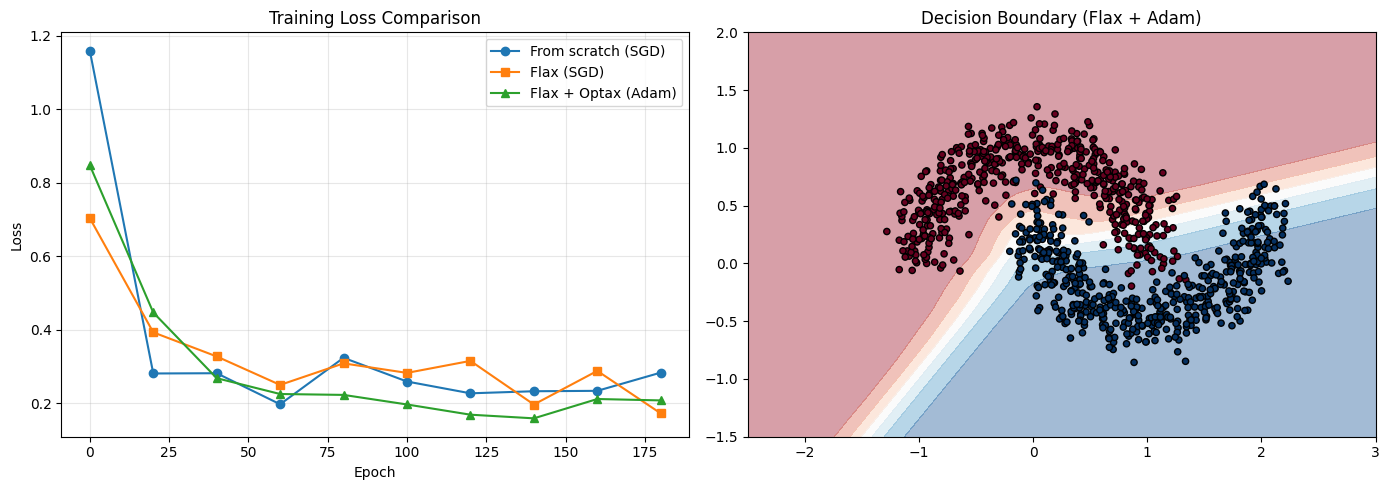

In [8]:
# Compare all three approaches
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_logged = list(range(0, 200, 20))
axes[0].plot(epochs_logged, losses_scratch, 'o-', label='From scratch (SGD)')
axes[0].plot(epochs_logged, losses_flax,   's-', label='Flax (SGD)')
axes[0].plot(epochs_logged, losses_optax,  '^-', label='Flax + Optax (Adam)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Comparison'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Decision boundary from Optax-trained model
xx, yy = np.meshgrid(np.linspace(-2.5, 3, 200), np.linspace(-1.5, 2, 200))
grid = jnp.array(np.c_[xx.ravel(), yy.ravel()], dtype=jnp.float32)
logits = model.apply({'params': params_optax}, grid)
probs = jax.nn.sigmoid(logits).reshape(xx.shape)

axes[1].contourf(xx, yy, np.array(probs), alpha=0.4, cmap='RdBu')
axes[1].scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='RdBu', edgecolors='k', s=20)
axes[1].set_title('Decision Boundary (Flax + Adam)')

plt.tight_layout(); plt.show()

---

# 5. For Inference Engineers

If your goal is **serving a trained model** rather than training from scratch, here's what you actually need:

```python
# At load time: run init once to get the param structure, then load saved weights
variables = model.init(jax.random.PRNGKey(0), x_dummy)  # get structure
params = load_checkpoint(path)                            # replace with actual weights

# At inference time: model.apply is a pure function — jit it once
@jax.jit
def predict(params, x):
    return model.apply({'params': params}, x)

# Every subsequent call uses the cached compiled version
output = predict(params, x_new)
```

`model.apply` is stateless and pure — it takes params and input, returns output. No hidden state, no mutation. This is what makes JAX models easy to deploy: the compiled function is just a mathematical computation on arrays.

> **Saving/loading weights**: Use [Orbax](https://orbax.readthedocs.io/) for checkpointing. It handles pytree serialization cleanly: `orbax.checkpoint.PyTreeCheckpointer().save(path, params)`.

---

# 6. Summary — What To Do Next

## The Three Training Layers

| Layer | Code | Manages | When to use |
|---|---|---|---|
| **From scratch** | `jax.tree.map(lambda p, g: p - lr * g, ...)` | Everything manually | Learning JAX; tiny experiments |
| **+ Flax** | `model.init` / `model.apply` | Parameter creation, layer shapes | Any real model |
| **+ Optax** | `optimizer.update` / `optax.apply_updates` | Optimizer state, update rule | Any real training |

## Key Takeaways

1. **Flax doesn't change the JAX model** — `params` is still a pytree, `grad` still works, `tree.map` still updates.
2. **`model.init(key, x_dummy)` returns `{'params': {...}}`** — a nested dict ready for `grad` and `jit`.
3. **`model.apply({'params': params}, x)` is a pure function** — safe to `jit`, `vmap`, and `grad` through.
4. **Optax follows the same pattern** — `opt_state` is a pytree, `optimizer.update` is a pure function.
5. **For inference**: `jit(model.apply)` is all you need. Load weights, compile once, serve forever.

## What's Next

- **[Optax docs](https://optax.readthedocs.io/)**: Adam, AdamW, cosine schedules, gradient clipping
- **[Flax training guides](https://flax.readthedocs.io/en/latest/guides/training_techniques/)**: multi-device training, dropout, batch normalization
- **[Orbax](https://orbax.readthedocs.io/)**: checkpointing and serialization
- **[MaxText](https://github.com/AI-Hypercomputer/maxtext)**: a reference LLM implementation — see these patterns at scale

In **Notebook 07: Control Flow**, we'll replace Python loops inside models with `lax.scan`, `lax.cond`, and `lax.while_loop` — essential for implementing RNNs, autoregressive decoders, and any model that iterates over sequences.

---

# Exercises

1. **Switch optimizer**: Replace `optax.adam` with `optax.sgd(learning_rate=0.05, momentum=0.9)`. How does convergence compare?

2. **Add a learning rate schedule**: Use `optax.cosine_decay_schedule` to decay from 1e-3 to 0 over 200 epochs. Chain it with the optimizer using `optax.chain`.

3. **Inspect the pytree**: After training with Optax, print the shapes and values of the first layer's weights and biases. Verify they differ from initialization.

4. **Inference benchmark**: `jit` the `model.apply` call and time the first call (compilation + inference) vs. the tenth call (inference only). How much is the first-call overhead?